# Tensor simplified

In [1]:
import torch

torch.__version__

'2.11.0+cu128'

In [2]:
#create a simple tensor
x = torch.tensor([[1, 2, 3], [4, 5, 6]])
y = torch.tensor([[7, 8, 9], [10, 11, 12]])

sum = x + y
print(sum)
print(sum.device)

tensor([[ 8, 10, 12],
        [14, 16, 18]])
cpu


In [3]:
#checking if gpu is available

if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

gpu_x = torch.tensor([[1, 2, 3], [4, 5, 6]], device=device)

# Running a pre-trained PyTorch model

In [4]:
import torch

use_gpu = True if torch.cuda.is_available() else False

# trained on high-quality celebrity faces "celebA" dataset
# this model outputs 512 x 512 pixel images
model = torch.hub.load(
        'facebookresearch/pytorch_GAN_zoo:hub', 'PGAN', model_name='celebAHQ-512', pretrained=True, useGPU=use_gpu
)

Using cache found in /home/dream/.cache/torch/hub/facebookresearch_pytorch_GAN_zoo_hub


Average network found !


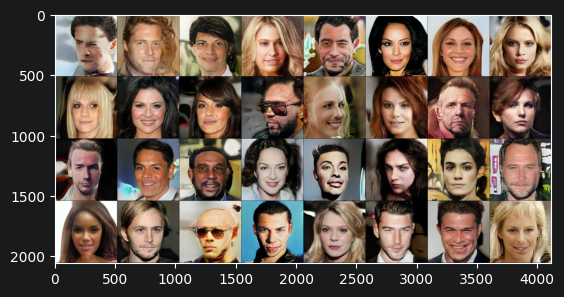

In [5]:
#lets generate few images
num_images = 32
noise, _ = model.buildNoiseData(num_images)

with torch.no_grad():
    generated_images = model.test(noise)

# let's plot these images using torchvision and matplotlib
import matplotlib.pyplot as plt
import torchvision

grid = torchvision.utils.make_grid(generated_images.clamp(min=-1, max=1), scale_each=True, normalize=True)
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())

In [6]:
type(noise)

torch.Tensor

In [7]:
noise

tensor([[-0.4807,  0.1683, -1.2613,  ..., -0.4787,  0.2018, -0.2986],
        [-0.1518, -0.1775,  1.2589,  ..., -0.7174,  0.3995,  0.6793],
        [ 2.2113,  0.8353,  1.4196,  ...,  0.0856, -1.8537, -0.3300],
        ...,
        [-1.1754,  0.4514, -0.6132,  ...,  2.1943,  0.3334, -2.0274],
        [ 1.3588, -0.3448, -1.1881,  ..., -1.3073, -0.6819,  0.7241],
        [ 2.0377,  0.3578,  0.2078,  ...,  0.0426,  1.1466,  0.3093]],
       device='cuda:0')

In [8]:
import torch

# Creating a 1D tensor from a Python list
tensor_1d = torch.tensor([1, 2, 3, 4, 5])
print(tensor_1d)

# Creating a 2D tensor (matrix) from a Python list of lists
tensor_2d = torch.tensor([[1, 2], [3, 4]])
print(tensor_2d)

tensor([1, 2, 3, 4, 5])
tensor([[1, 2],
        [3, 4]])


In [9]:
# Element-wise addition
tensor_a = torch.tensor([1, 2, 3])
tensor_b = torch.tensor([4, 5, 6])
result = tensor_a + tensor_b
print(result)  # Output: tensor([5, 7, 9])

# Element-wise multiplication
result = tensor_a * tensor_b
print(result)  # Output: tensor([ 4, 10, 18])

# Element-wise division
result = tensor_b / tensor_a
print(result)  # Output: tensor([4., 2.5, 2.])

tensor([5, 7, 9])
tensor([ 4, 10, 18])
tensor([4.0000, 2.5000, 2.0000])


In [10]:
# Matrix multiplication
matrix_a = torch.tensor([[1, 2], [3, 4]])
matrix_b = torch.tensor([[5, 6], [7, 8]])
result = torch.matmul(matrix_a, matrix_b)
print(result)  # Output: tensor([[19, 22], [43, 50]])

# Transpose of a matrix
result = matrix_a.T
print(result)  # Output: tensor([[1, 3], [2, 4]])

# Dot product of two vectors
vector_a = torch.tensor([1, 2, 3])
vector_b = torch.tensor([4, 5, 6])
result = torch.dot(vector_a, vector_b)
print(result)  # Output: tensor(32)

tensor([[19, 22],
        [43, 50]])
tensor([[1, 3],
        [2, 4]])
tensor(32)


In [11]:
#Reduction Operations
tensor = torch.tensor([1, 2, 3, 4, 5])

#sum of all elements in tensor
sum = torch.sum(tensor)
print(sum)

#Mean of all elements in tensor
mean = torch.mean(tensor.float())
print(mean)

#Maximum and Minimum Elements in tensor
max = torch.max(tensor)
min = torch.min(tensor)

print("max ", max)
print("min ", min)

tensor(15)
tensor(3.)
max  tensor(5)
min  tensor(1)


In [12]:
#Reshaping Operation

import torch

unshaped_tensor = torch.tensor([[1, 2, 3], [4, 5, 6]])

#reshaping 2*3 tensor into 3*2 tensor
reshaped_tensor = unshaped_tensor.view(3, 2)
print(reshaped_tensor)

tensor([[1, 2],
        [3, 4],
        [5, 6]])


In [13]:
#Squeezing Operation
tensor = torch.tensor([[[1, 2]]])
print(tensor.size())

#Squeezing tensor
squeezed_tensor = tensor.squeeze()
print(squeezed_tensor)
print(squeezed_tensor.size())

torch.Size([1, 1, 2])
tensor([1, 2])
torch.Size([2])


In [14]:
import torch

#UnSqueezing

ten = torch.tensor([1, 2, 3])
print(ten.shape)

#unsqueeze to make it 2d tensor 1*3
unsqueezed_tensor = ten.unsqueeze(0)
print(unsqueezed_tensor)

print("**** Unsqueezing to make it 2d tensor (3*1)")

unsqueezed_tensor = ten.unsqueeze(1)
print(unsqueezed_tensor)

torch.Size([3])
tensor([[1, 2, 3]])
**** Unsqueezing to make it 2d tensor (3*1)
tensor([[1],
        [2],
        [3]])


# Linear regression with Pytorch

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [16]:
np.random.seed(42)
X = np.random.rand(100, 1) * 10
y = 2 * X + 3 + np.random.randn(100, 1)

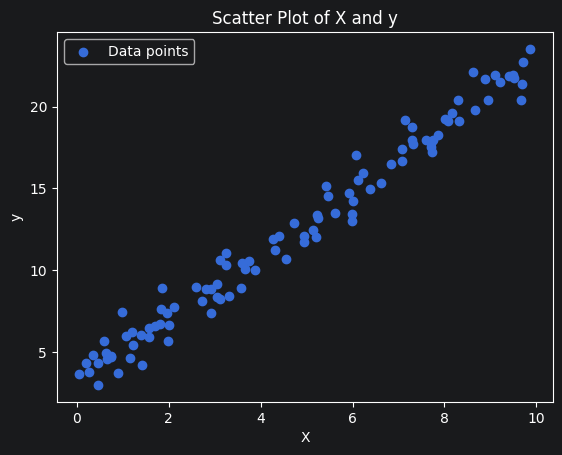

In [17]:
# Creating the scatter plot
plt.scatter(X, y, label='Data points')

# Adding labels and title
plt.xlabel('X')
plt.ylabel('y')
plt.title('Scatter Plot of X and y')

# Adding a legend
plt.legend()

# Displaying the plot
plt.show()

In [18]:
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)


def linear_regression(input_size, output_size):
    return nn.Linear(input_size, output_size)


input_size = 1
output_size = 1
model = linear_regression(input_size, output_size)

# pytorch.nn module

In [19]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [20]:
num_epochs = 1000

for epoch in range(num_epochs):
    y_pred = model(X_tensor)
    loss = criterion(y_pred, y_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [100/1000], Loss: 1.3666
Epoch [200/1000], Loss: 0.9907
Epoch [300/1000], Loss: 0.8671
Epoch [400/1000], Loss: 0.8265
Epoch [500/1000], Loss: 0.8131
Epoch [600/1000], Loss: 0.8087
Epoch [700/1000], Loss: 0.8073
Epoch [800/1000], Loss: 0.8068
Epoch [900/1000], Loss: 0.8067
Epoch [1000/1000], Loss: 0.8066


# Improving linear neural network

In [21]:
def linear_regression(input_size, output_size):
    return nn.Linear(input_size, output_size)

In [22]:
# Parameters
num_points = 200
x_range = np.linspace(0, 10, num_points)
noise = np.random.normal(0, 0.3, num_points)

# Generate zigzag points
y = np.sin(x_range) + noise

In [23]:
# Define a simple neural network using a sequential module
model = nn.Sequential(
        nn.Linear(1, 50),  # Input layer: 1 input feature, 50 neurons
        nn.Tanh(),  # Activation function
        nn.Linear(50, 1)  # Output layer: 50 neurons, 1 output feature
)

In [24]:
# Training loop
num_epochs = 10000

for epoch in range(num_epochs):
    # Forward pass
    # print(x_data.unsqueeze(1).shape)
    y_pred = model(torch.from_numpy(x_range).float().unsqueeze(1))
    loss = criterion(y_pred, torch.from_numpy(y).float().unsqueeze(1))

    # Backpropagation and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [100/10000], Loss: 0.8358
Epoch [200/10000], Loss: 0.8358
Epoch [300/10000], Loss: 0.8358
Epoch [400/10000], Loss: 0.8358
Epoch [500/10000], Loss: 0.8358
Epoch [600/10000], Loss: 0.8358
Epoch [700/10000], Loss: 0.8358
Epoch [800/10000], Loss: 0.8358
Epoch [900/10000], Loss: 0.8358
Epoch [1000/10000], Loss: 0.8358
Epoch [1100/10000], Loss: 0.8358
Epoch [1200/10000], Loss: 0.8358
Epoch [1300/10000], Loss: 0.8358
Epoch [1400/10000], Loss: 0.8358
Epoch [1500/10000], Loss: 0.8358
Epoch [1600/10000], Loss: 0.8358
Epoch [1700/10000], Loss: 0.8358
Epoch [1800/10000], Loss: 0.8358
Epoch [1900/10000], Loss: 0.8358
Epoch [2000/10000], Loss: 0.8358
Epoch [2100/10000], Loss: 0.8358
Epoch [2200/10000], Loss: 0.8358
Epoch [2300/10000], Loss: 0.8358
Epoch [2400/10000], Loss: 0.8358
Epoch [2500/10000], Loss: 0.8358
Epoch [2600/10000], Loss: 0.8358
Epoch [2700/10000], Loss: 0.8358
Epoch [2800/10000], Loss: 0.8358
Epoch [2900/10000], Loss: 0.8358
Epoch [3000/10000], Loss: 0.8358
Epoch [3100/10000],

# Simple classification as example of non-linearity

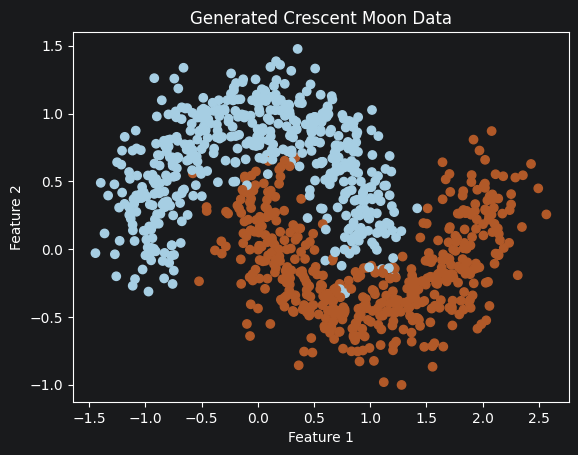

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic crescent moon dataset
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

# Visualize the generated data
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired)
plt.title("Generated Crescent Moon Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [26]:
# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.int64)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.int64)

# Define a simple neural network architecture
model = nn.Sequential(nn.Linear(2, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 2))

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [27]:
# Training loop
num_epochs = 1000

for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch [{epoch}/{num_epochs}] - Loss: {loss.item():.4f}")

print("Training Finished")

Epoch [0/1000] - Loss: 0.6893
Epoch [100/1000] - Loss: 0.1966
Epoch [200/1000] - Loss: 0.0904
Epoch [300/1000] - Loss: 0.0692
Epoch [400/1000] - Loss: 0.0631
Epoch [500/1000] - Loss: 0.0609
Epoch [600/1000] - Loss: 0.0597
Epoch [700/1000] - Loss: 0.0589
Epoch [800/1000] - Loss: 0.0582
Epoch [900/1000] - Loss: 0.0576
Training Finished


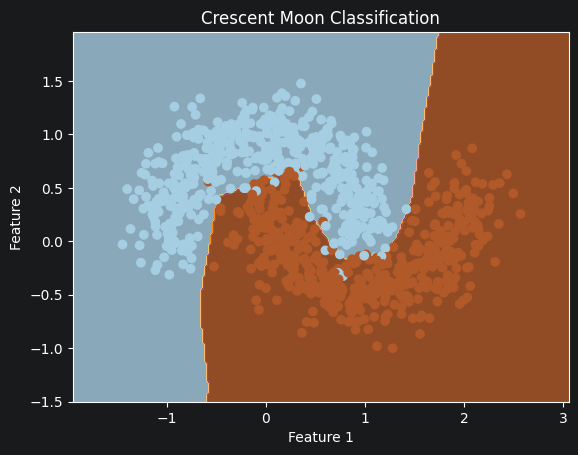

In [28]:
# Evaluate the model on a grid for visualization
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

grid_tensor = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
model.eval()

with torch.no_grad():
    Z = model(grid_tensor)

Z = torch.argmax(Z, dim=1)
Z = Z.numpy()
Z = Z.reshape(xx.shape)

# Plotting the data points and classification boundary
plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired)
plt.title("Crescent Moon Classification")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()